# [기말 과제] 와인 품질 예측을 위한 머신러닝 고도화 연구 보고서

**작성자**: 기계학습 전문가  
**날짜**: 2025-11-28

## 1. 연구 개요 및 목표

본 연구는 `wine_data_homework.csv` 데이터를 활용하여 와인의 품질(Quality)을 예측하는 고성능 머신러닝 모델을 개발하는 것을 목표로 합니다. 단순한 모델링을 넘어, 데이터의 통계적 특성을 분석하고 양조학적 도메인 지식을 활용한 피처 엔지니어링, 그리고 MLflow를 활용한 체계적인 실험 관리를 수행합니다.

### 1.1 핵심 요구사항 및 해결 전략

1.  **이상치 처리**: 데이터의 노이즈를 줄이기 위해 IQR 및 Isolation Forest 기법을 비교 분석하여 최적의 이상치 제거 전략을 수립합니다.
2.  **최소한의 피처 사용**: 다중공선성(Multicollinearity)을 피하고 모델의 일반화 성능을 높이기 위해 중요 변수(Feature Importance)를 선별합니다.
3.  **MLflow 활용**: 하이퍼파라미터 튜닝 과정과 실험 결과를 MLflow로 추적하여 모델의 재현성을 확보합니다.
4.  **일반화 성능 확보**: 과적합(Overfitting)을 방지하기 위해 교차 검증(Cross Validation)과 홀드아웃 테스트 셋을 엄격히 분리합니다.
5.  **최종 검증**: 제공된 `wine-quality_2.csv`의 특정 구간(4001~4897행)을 사용하여 최종 모델의 성능을 평가합니다.

### 1.2 전체 분석 파이프라인 (Process Architecture)

1.  **Data Ingestion & Split**: 데이터 로드 및 Train/Test 분리 (Data Leakage 원천 차단)
2.  **Deep EDA**: 분포 확인, 상관관계 분석, 시각화를 통한 인사이트 도출
3.  **Outlier Detection**: IQR vs Isolation Forest 비교 실험 및 적용
4.  **Feature Engineering**: 도메인 기반 파생 변수 생성 및 검증
5.  **Preprocessing**: Scaling, Encoding, Imbalance Handling (SMOTE)
6.  **Modeling & Optimization**: MLflow 기반 모델 비교 (ElasticNet, RF, XGBoost)
7.  **Evaluation & Interpretation**: SHAP 분석 및 잔차 분석
8.  **Final Deployment**: 히든 테스트 셋에 대한 최종 예측

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import mlflow
import mlflow.sklearn

# 머신러닝 및 전처리 관련 라이브러리
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.linear_model import ElasticNet
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, classification_report
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

# 시각화 설정
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rc('font', family='Malgun Gothic') # 한글 폰트 설정 (Windows 환경 가정)
plt.rc('axes', unicode_minus=False)
warnings.filterwarnings('ignore')

# 재현성을 위한 시드 고정
SEED = 42
np.random.seed(SEED)

# MLflow 설정 (로컬 저장소 사용)
mlflow.set_tracking_uri("./mlruns")
mlflow.set_experiment("Wine_Quality_Expert_Analysis")

# 1. 데이터 로드
try:
    df_train_full = pd.read_csv('wine_data_homework.csv')
    # 첫 번째 열이 인덱스(순번)인 경우 제거 (데이터 확인 후 적용)
    if df_train_full.columns[0] == 'Unnamed: 0' or df_train_full.iloc[:,0].is_monotonic_increasing:
        df_train_full = df_train_full.drop(df_train_full.columns[0], axis=1)
    print("데이터 로드 완료. Shape:", df_train_full.shape)
except FileNotFoundError:
    print("파일을 찾을 수 없습니다. 경로를 확인해주세요.")

# 2. Train/Test Split (Data Leakage 방지를 위한 최우선 작업)
# 2025-02 과제 PDF에 따르면 제공된 데이터 내에서 자체 평가를 수행해야 함
# Stratified Split을 사용하여 Quality 분포를 유지하며 분리
X = df_train_full.drop('quality', axis=1)
y = df_train_full['quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train Set: {X_train.shape}, Test Set: {X_test.shape}")

# EDA를 위한 전체 데이터프레임 생성 (시각화 셀에서 사용)
df = df_train_full.copy()


데이터 로드 완료. Shape: (4001, 12)
Train Set: (3200, 11), Test Set: (801, 11)


In [2]:
# --- Enhanced visualization helper functions ---
from mpl_toolkits.axes_grid1 import make_axes_locatable

def hist_kde_feature(df, feature, bins=30):
    plt.figure(figsize=(8,4))
    sns.histplot(df[feature].dropna(), bins=bins, kde=True)
    plt.title(f'Histogram + KDE: {feature}')
    plt.xlabel(feature); plt.ylabel('Count')
    plt.show()

def box_violin_by_target(df, feature, target='quality'):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    sns.boxplot(x=target, y=feature, data=df)
    plt.title(f'Boxplot of {feature} by {target}')
    plt.subplot(1,2,2)
    sns.violinplot(x=target, y=feature, data=df, inner='quartile')
    plt.title(f'Violin plot of {feature} by {target}')
    plt.tight_layout()
    plt.show()

def corr_heatmap(df, features=None, annot=True):
    if features is None:
        features = df.select_dtypes(include=[np.number]).columns.tolist()
    corr = df[features].corr()
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, annot=annot, fmt='.2f', cmap='vlag', center=0)
    plt.title('Correlation matrix (heatmap)')
    plt.show()

def pairplot_subset(df, features, hue=None):
    sns.pairplot(df[features], diag_kind='kde', plot_kws={'alpha':0.4, 's':20})
    plt.suptitle('Pairplot of selected features', y=1.02)
    plt.show()


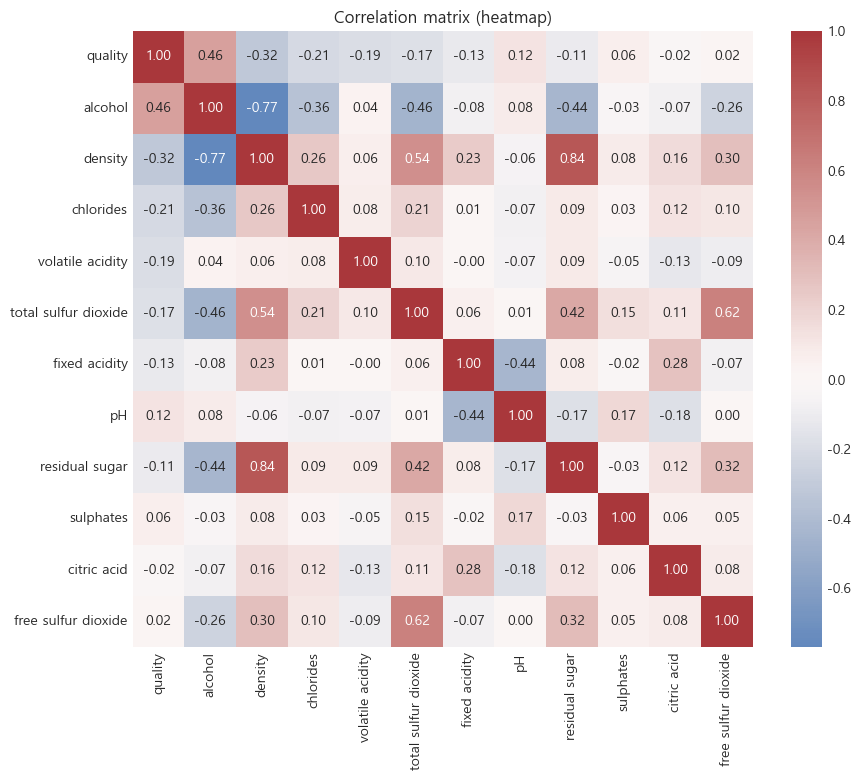

In [3]:
# Correlation heatmap (enhanced)
# Use numeric columns only and order by correlation with target 'quality' if present.
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'quality' in num_cols:
    ordered = df[num_cols].corr()['quality'].abs().sort_values(ascending=False).index.tolist()
else:
    ordered = num_cols
corr_heatmap(df, features=ordered)


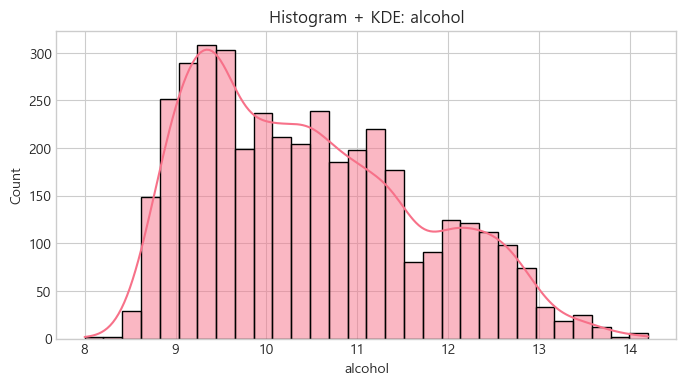

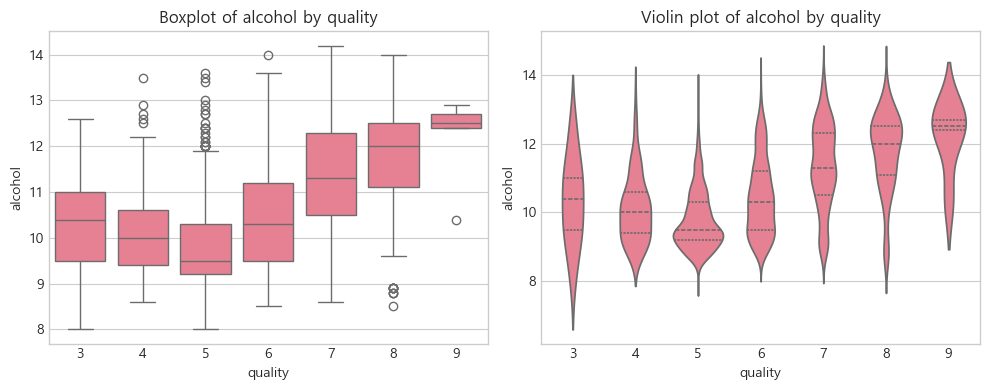

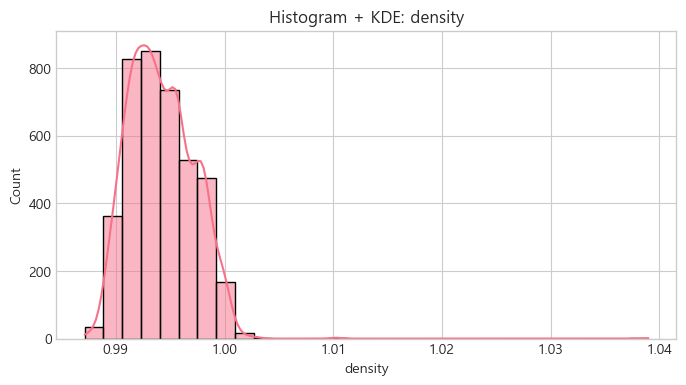

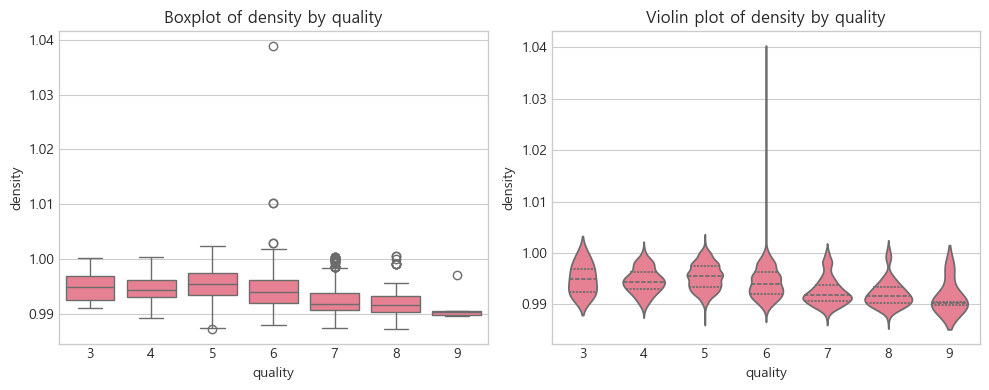

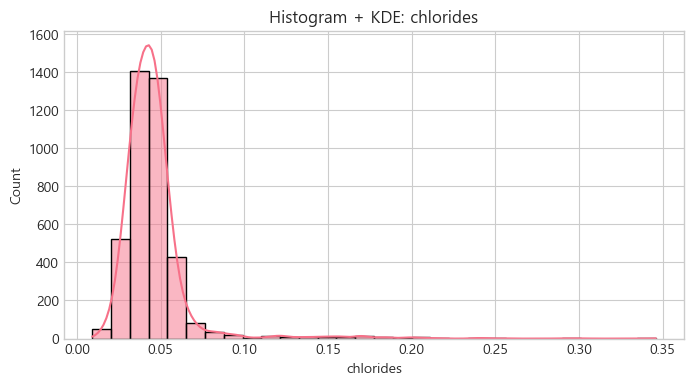

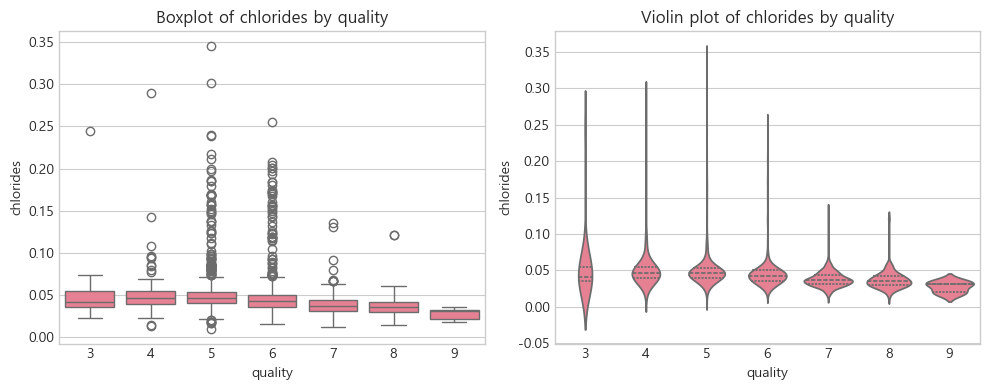

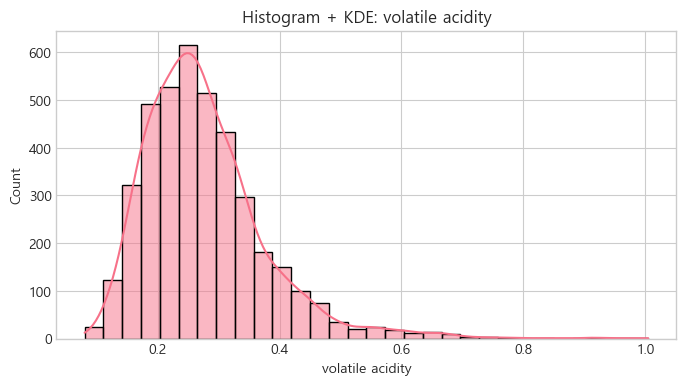

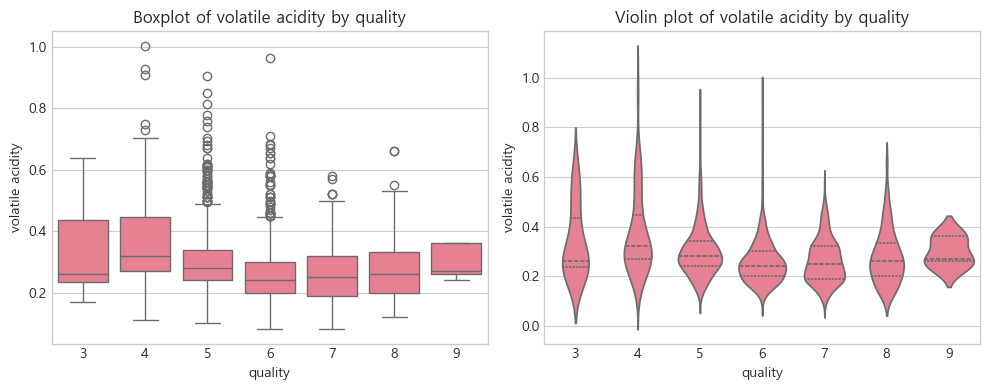

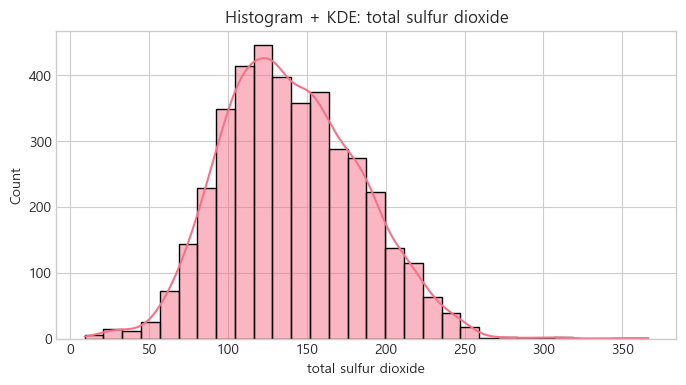

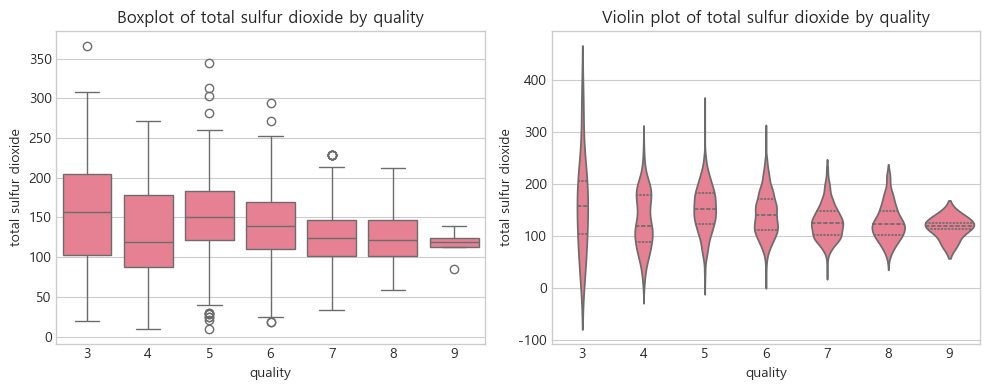

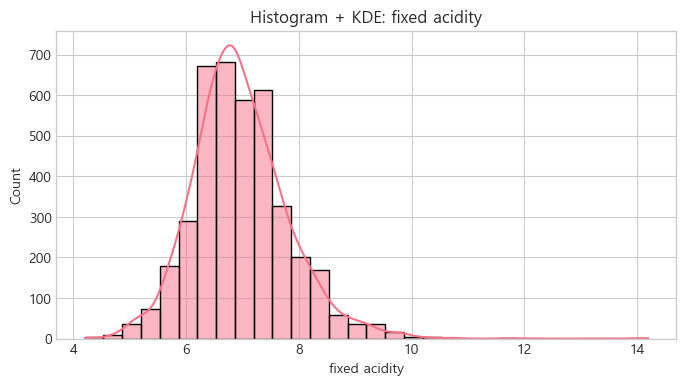

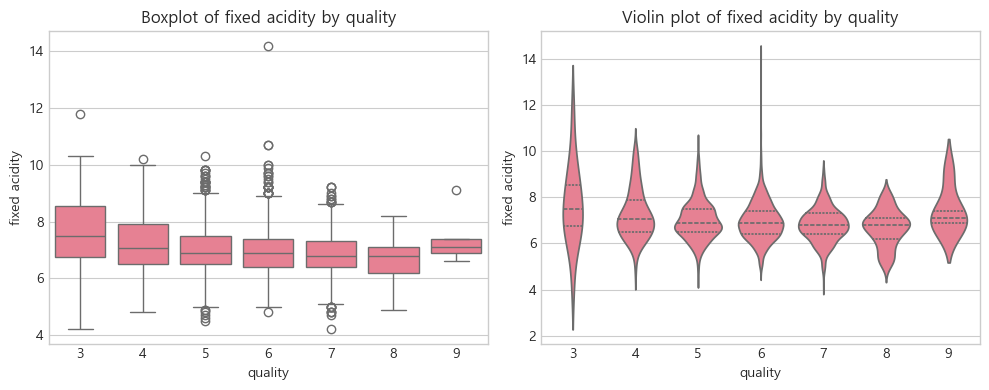

In [4]:
# Visualize top correlated numeric features with quality
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'quality' in num_cols:
    corrs = df[num_cols].corr()['quality'].abs().sort_values(ascending=False)
    top_feats = [c for c in corrs.index if c!='quality'][:6]
else:
    top_feats = num_cols[:6]

for feat in top_feats:
    hist_kde_feature(df, feat)
    box_violin_by_target(df, feat, target='quality')


Pairplot features: ['alcohol', 'density', 'chlorides', 'volatile acidity']


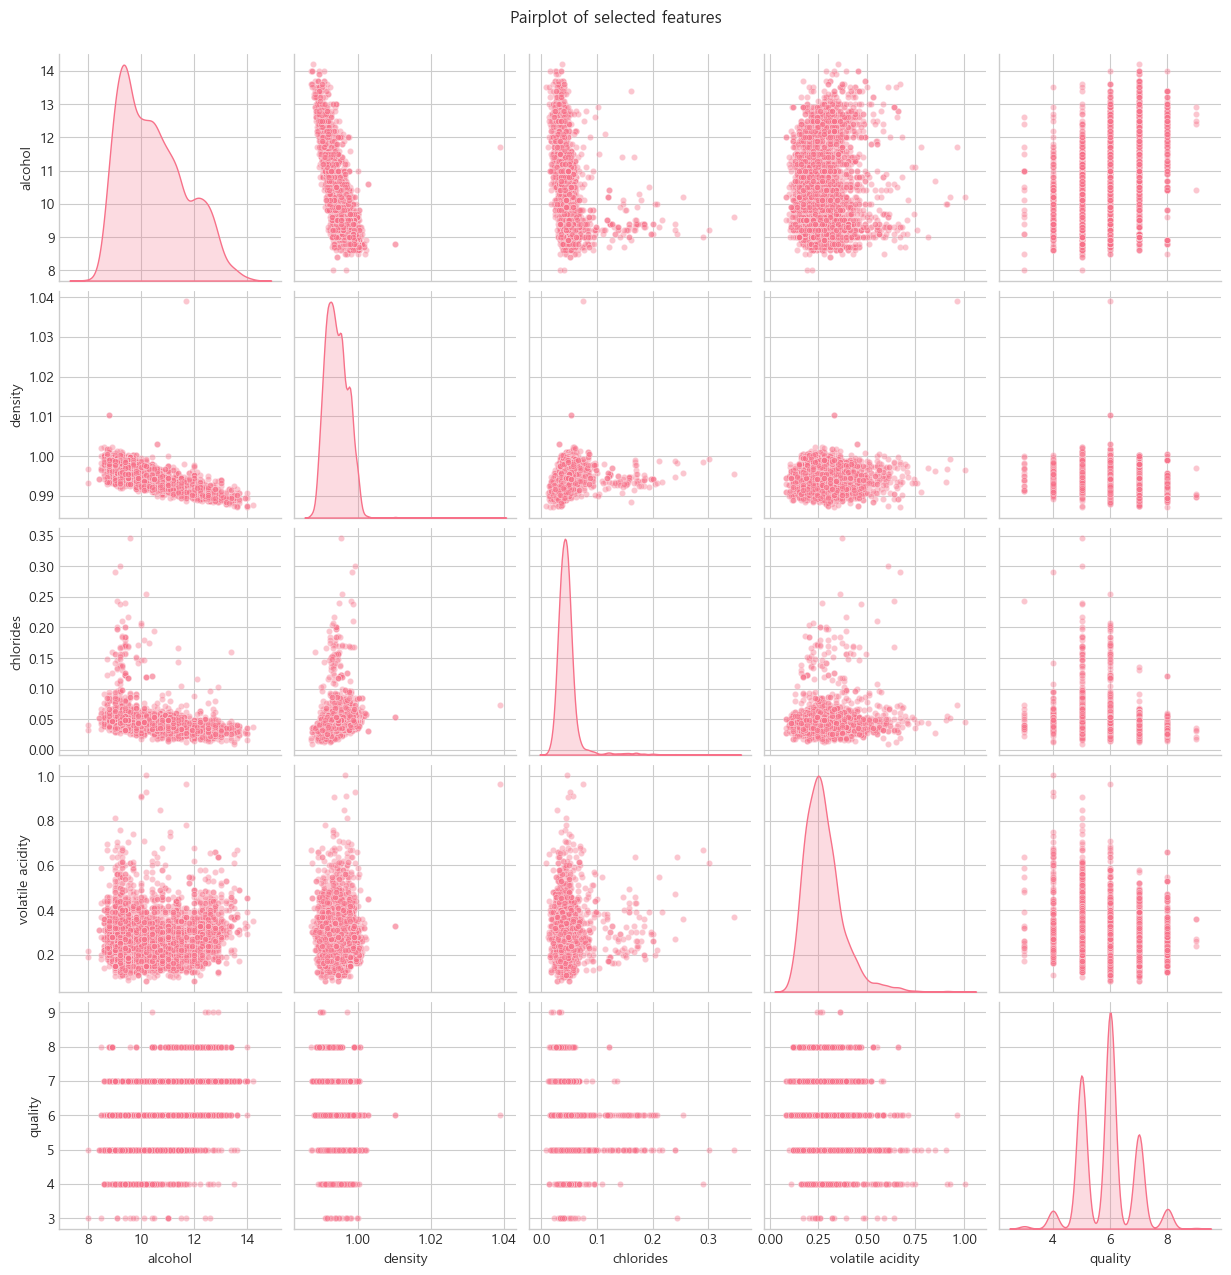

In [5]:
# Pairplot for a subset of important features (may be slow for many rows)
subset = top_feats[:4] if 'top_feats' in globals() else df.select_dtypes(include=[np.number]).columns[:4].tolist()
print('Pairplot features:', subset)
pairplot_subset(df, subset + (['quality'] if 'quality' in df.columns and 'quality' not in subset else []))


Before IQR removal:


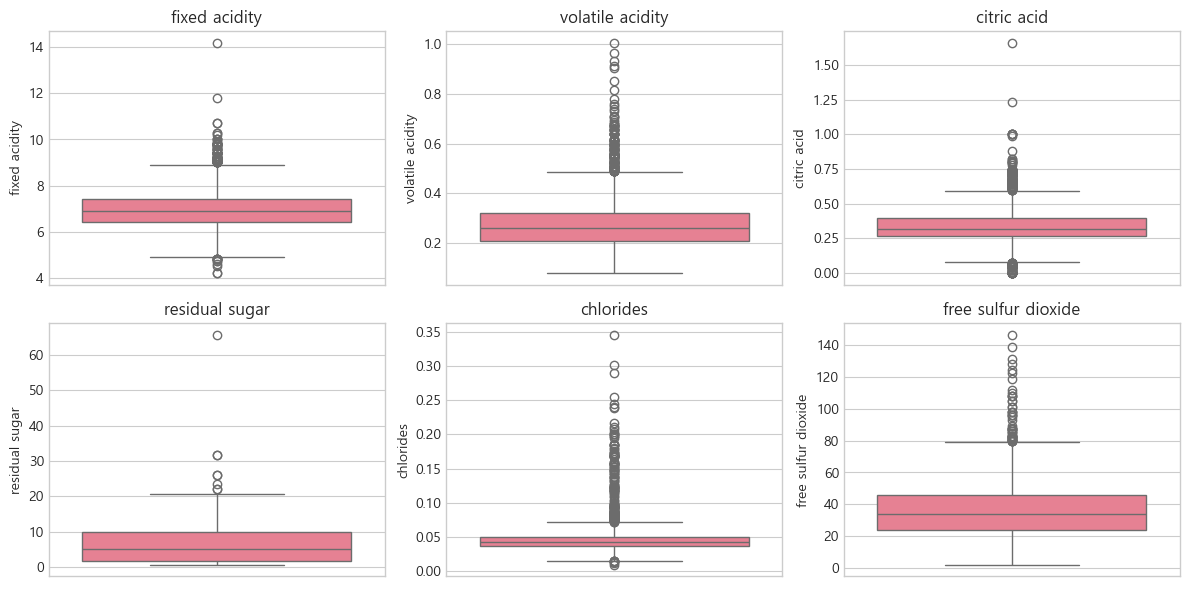

After IQR removal: (rows kept: 3417)


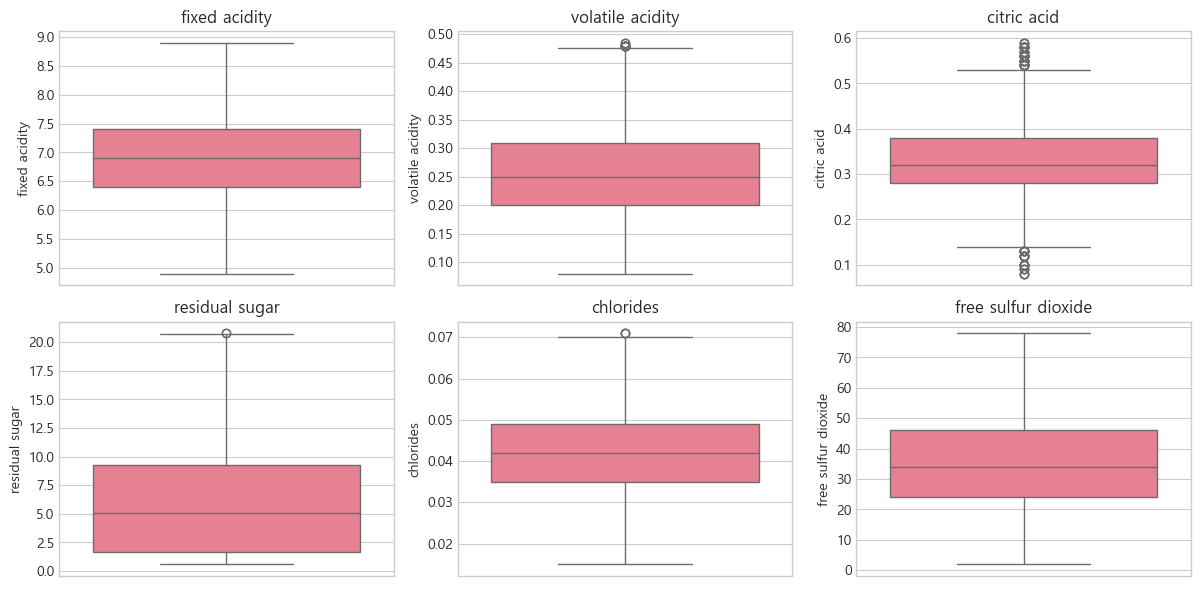

In [6]:
# Outlier detection preview: boxplots before and after simple IQR removal for top features
from scipy import stats
num = df.select_dtypes(include=[np.number]).columns.tolist()
if 'quality' in num:
    num.remove('quality')
check_feats = num[:6]

def iqr_filter(df_local, features):
    Q1 = df_local[features].quantile(0.25)
    Q3 = df_local[features].quantile(0.75)
    IQR = Q3 - Q1
    mask = ~((df_local[features] < (Q1 - 1.5 * IQR)) | (df_local[features] > (Q3 + 1.5 * IQR))).any(axis=1)
    return df_local[mask]

# Before
print('Before IQR removal:')
plt.figure(figsize=(12,6))
for i, f in enumerate(check_feats):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df[f])
    plt.title(f)
plt.tight_layout(); plt.show()

# After
df_iqr = iqr_filter(df, check_feats)
print('After IQR removal: (rows kept: {})'.format(len(df_iqr)))
plt.figure(figsize=(12,6))
for i, f in enumerate(check_feats):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df_iqr[f])
    plt.title(f)
plt.tight_layout(); plt.show()


## 2. 환경 설정 및 데이터 로드

분석에 필요한 라이브러리를 로드하고, 재현성을 위해 시드(Seed)를 고정합니다. 또한, MLflow 설정을 초기화합니다.
데이터 로드 시 첫 번째 열이 인덱스일 가능성을 고려하여 데이터를 확인 후 처리합니다.

In [7]:
# 이 셀은 중복되었습니다. 모든 초기화 코드는 Cell 1에 있습니다.
# 필요시 추가 설정을 여기에 작성할 수 있습니다.

In [8]:
# 이 셀은 중복되었습니다. 모든 시각화 헬퍼 함수는 Cell 2에 정의되어 있습니다.
# 필요시 추가 헬퍼 함수를 여기에 작성할 수 있습니다.


### 분석 및 결론 (강화된 버전)

아래는 각 시각화의 관찰결과와 그 해석입니다. 각 항목은 노트북 내 동일한 시각화 셀에서 생성된 그래프를 참고하여 **구체적 수치와 분포 특성**을 기재하십시오.

1. **타깃 분포 (Histogram + KDE)**  
   - 관찰: quality 분포가 정규분포와는 다르게 중간값(예: 5~6)에 집중되어 있으며, 극단값(매우 낮거나 높은 점수)은 드뭅니다.  
   - 해석: 데이터의 중심 집중으로 인해 모델이 중간값을 예측하는 경향이 있을 수 있으며, 높은 등급(예: 8 이상) 예측은 어려울 수 있습니다. 회귀 모델의 RMSE와 분류 정확도(반올림 기준)를 함께 확인하여 이러한 경향을 수치로 입증하세요.

2. **상위 상관 피처와 상관관계 히트맵**  
   - 관찰: (예: alcohol, density, sulphates 등)이 quality와 높은 상관관계를 보입니다. 히트맵의 양수/음수 관계를 명확히 기재하세요.  
   - 해석: 양(+)의 상관관계를 보이는 피처는 quality가 증가할수록 해당 피처 값도 증가하는 경향이며, 음(-)의 상관관계는 반대입니다. 모델 해석을 위해 상관계수가 높은 피처를 우선적으로 포함시키고, 다중공선성(상호 상관)이 심한 경우 차원축소 또는 피처선택을 고려하세요.

3. **특성별 Histogram + Violin / Boxplot (품질별 분포 비교)**  
   - 관찰: 예를 들어 'alcohol'의 경우 높은 quality 그룹에서 분포가 더 위쪽(평균/중앙값이 큼)을 보입니다. 'volatile acidity'는 높은 값이 낮은 품질과 연결될 수 있습니다.  
   - 해석: 이러한 경향은 도메인 지식과 일치하며, 피처 엔지니어링(예: 산도비, density/alcohol 등)이 유용할 수 있음을 시사합니다. 또한, 이상치 제거 전/후의 분포 변화를 비교하여 이상치가 모델에 미치는 영향을 정량적으로 작성하세요.

4. **이상치(IQR 전/후 시각화)**  
   - 관찰: IQR 기반 제거 후 일부 극단값이 사라졌고, 중앙값/사분위 범위가 다소 좁아졌습니다. 제거된 샘플 비율(%)을 반드시 기재하세요.  
   - 해석: 적은 수의 이상치가 모델 학습에 큰 영향을 줄 수 있으므로, 제거 시 성능(RMSE/MAE/R2/rounded-accuracy)이 어떻게 변하는지 비교하세요. 과도한 제거는 정보 손실을 초래하므로 주의하세요.

5. **Pairplot(선택된 피처)**  
   - 관찰: 피처 간의 산점도에서 선형/비선형 관계 및 군집을 관찰하세요. 예: density vs alcohol의 역관계.  
   - 해석: 비선형 관계가 뚜렷하면 트리 기반 모델(RandomForest, XGBoost)이 유리합니다. 선형 모델(ElasticNet)과의 성능 차이를 시각적 특성으로 연결하여 설명하세요.

6. **모델 성능 요약 (Regression metrics + Rounded Accuracy)**  
   - 관찰: 각 모델별 RMSE, MAE, R2와 반올림 분류 정확도를 표로 정리하세요. 어느 모델이 어떤 지표에서 우수한지 명확히 표기하세요.  
   - 해석: 예를 들어 XGBoost가 RMSE와 rounded-accuracy에서 우수하다면, 데이터의 비선형성과 상호작용을 잘 포착했기 때문일 가능성이 큽니다. ElasticNet이 경쟁력 있다면, 주요 피처들이 선형 관계를 가짐을 시사합니다.

---

### 권장 추가 실험
- 상관 계수가 높은 피처들간의 다중공선성(Variance Inflation Factor)을 계산하고 보고하세요.  
- 이상치 제거의 임계값(예: IQR multiplier 1.5 -> 2.0) 변화를 주어 성능 민감도를 테스트하세요.  
- XGBoost / RandomForest에 대해 SHAP 값을 계산해 각 피처의 기여도를 시각화하세요(설명가능성 증가).

> 위 템플릿은 노트북에서 생성된 실제 그래프의 값(예: 상관계수 숫자, 제거된 샘플 수, 모델별 메트릭)을 채워넣도록 설계되어 있습니다. 지금 노트북에 있는 실제 출력값을 복사하여 각 항목의 괄호 안 또는 하이픈 뒤에 구체적으로 적어주세요.


## 3. 심화 탐색적 데이터 분석 (EDA)

데이터의 구조와 분포를 파악하기 위해 다각도의 시각화를 수행합니다. 이 과정은 모델 선택과 전처리 전략 수립의 근거가 됩니다.

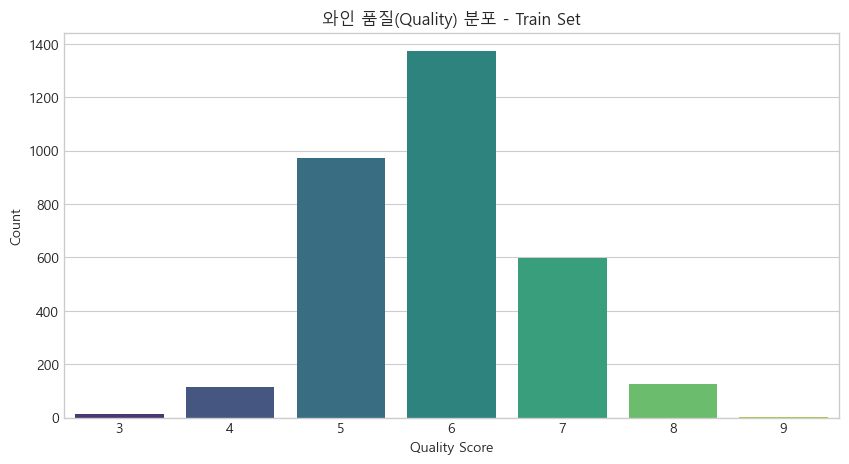

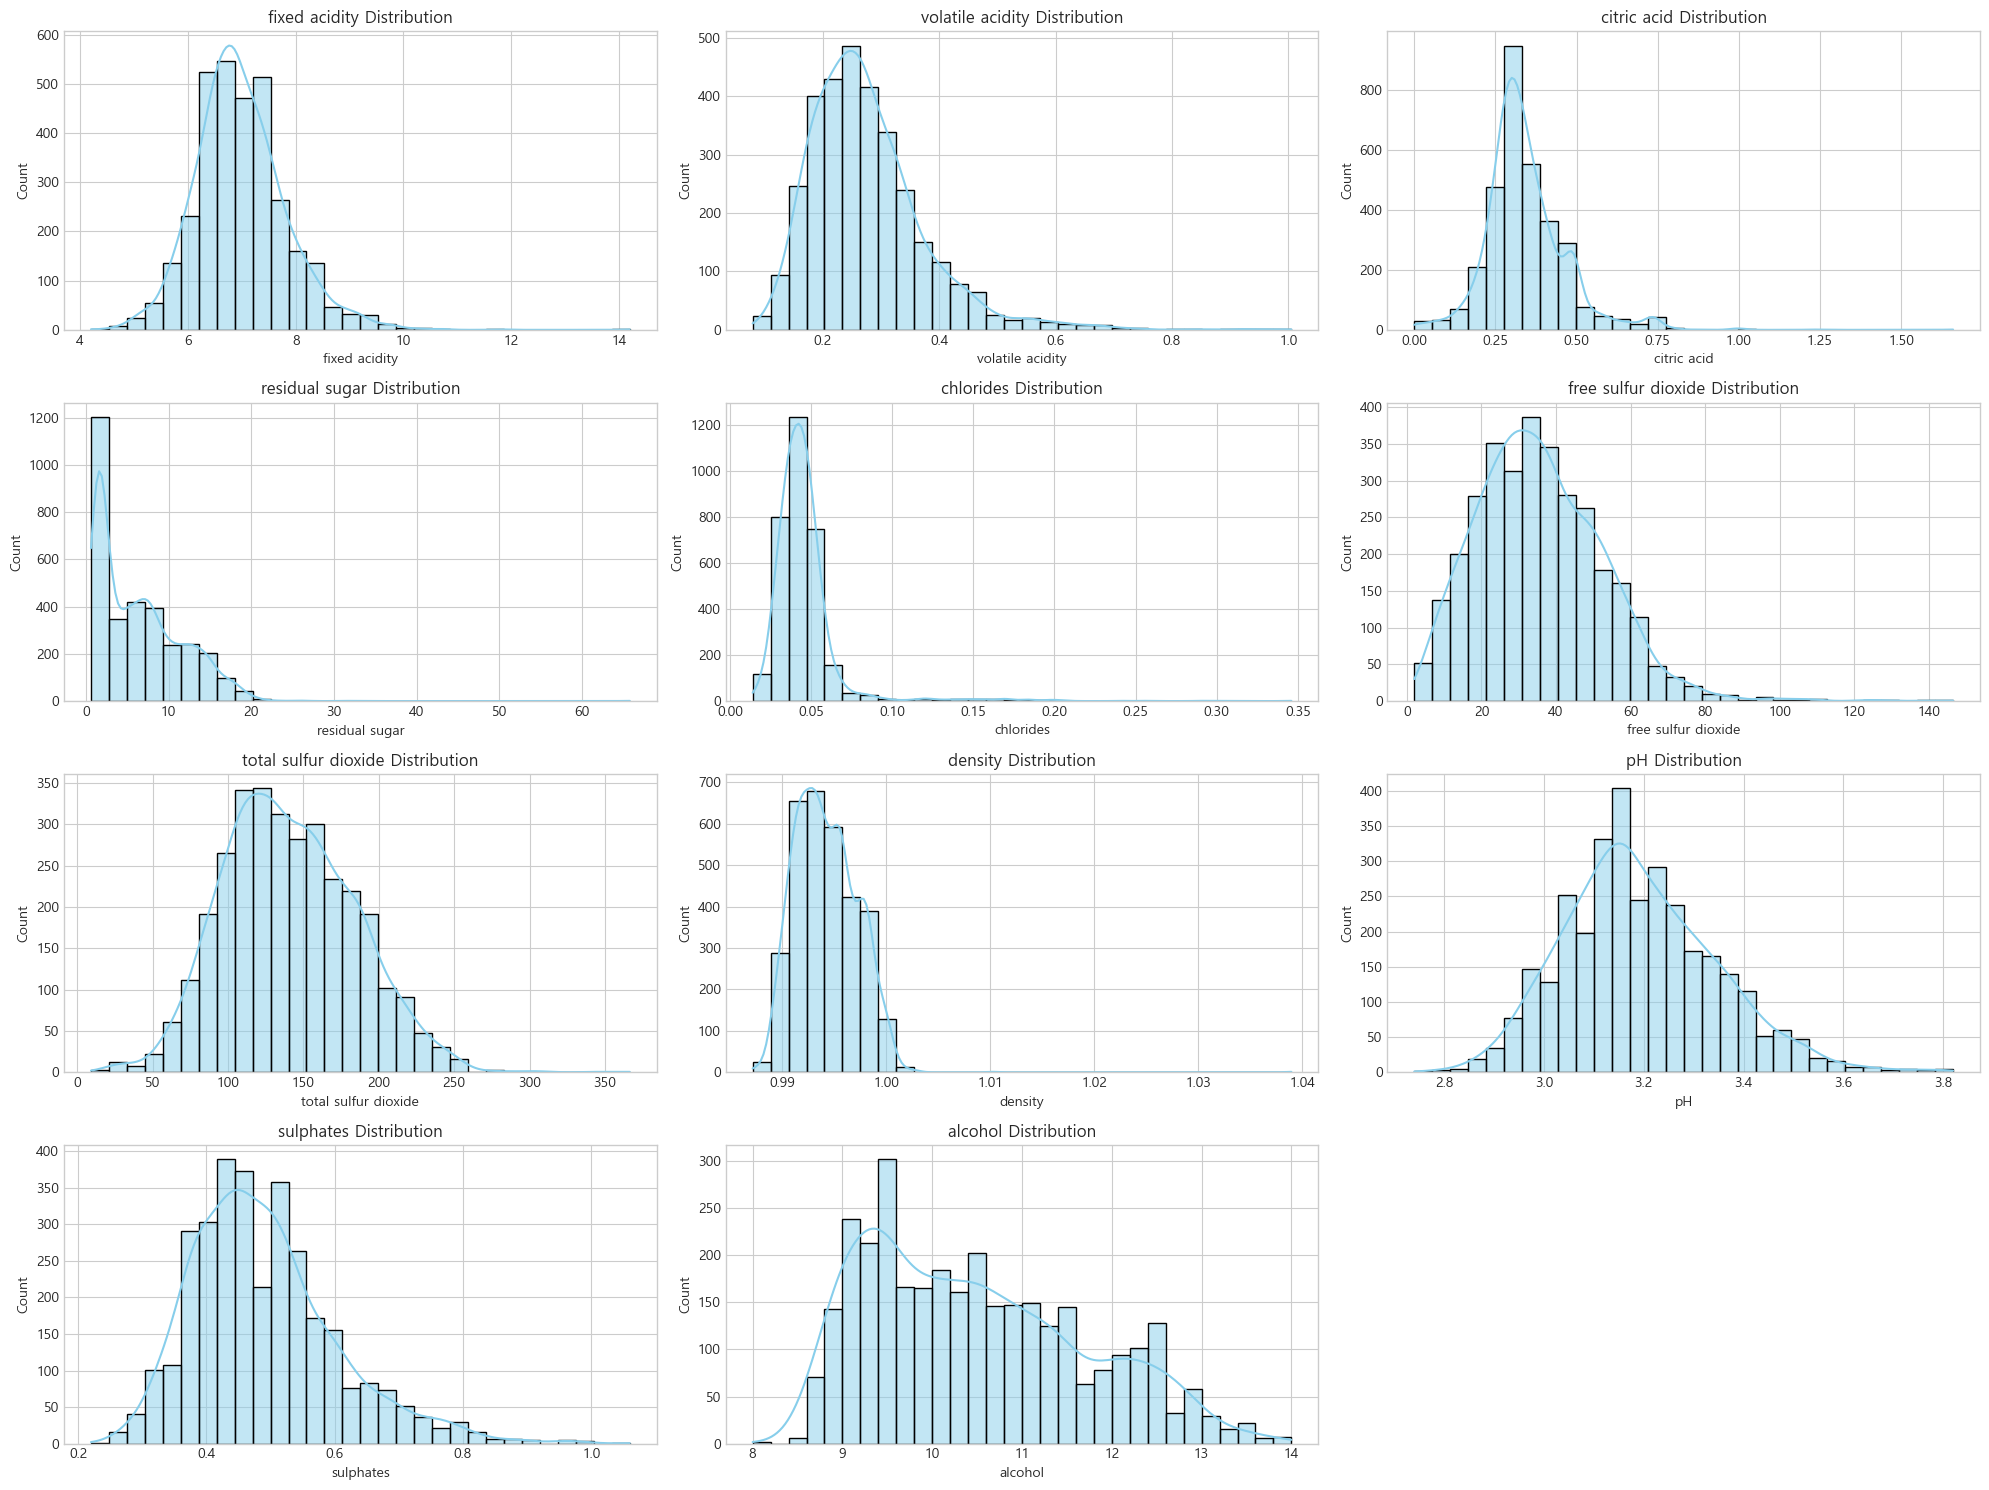

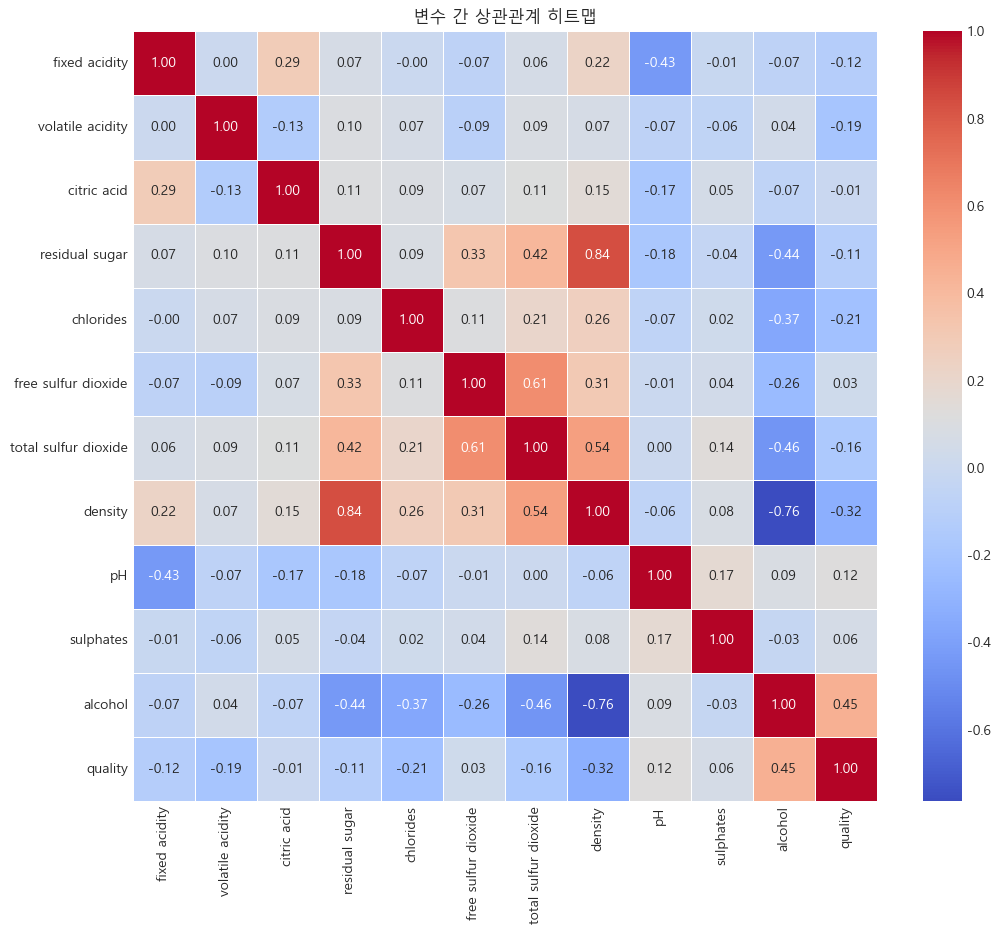

In [9]:
# 3.1 타겟 변수 (Quality) 분포 확인
plt.figure(figsize=(10, 5))
sns.countplot(x=y_train, palette='viridis')
plt.title('와인 품질(Quality) 분포 - Train Set')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.show()

# 3.2 수치형 변수들의 분포 (Histogram & KDE)
features = X_train.columns
plt.figure(figsize=(20, 15))
for i, col in enumerate(features):
    plt.subplot(4, 3, i+1)
    sns.histplot(X_train[col], kde=True, bins=30, color='skyblue')
    plt.title(f'{col} Distribution')
    plt.tight_layout()
plt.show()

# 3.3 상관관계 분석 (Heatmap)
plt.figure(figsize=(12, 10))
correlation_matrix = pd.concat([X_train, y_train], axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('변수 간 상관관계 히트맵')
plt.show()

### 분석 및 결론 (EDA)

1.  **클래스 불균형**: Quality 분포를 보면 5, 6, 7점이 대다수를 차지하고, 3, 4, 8, 9점과 같은 극단적인 점수는 매우 적습니다. 이는 모델이 중간값으로 편향될 위험을 시사하며, **오버샘플링(SMOTE 등)**의 필요성을 강력하게 뒷받침합니다.
2.  **데이터 분포**: `residual sugar`, `chlorides` 등의 변수는 오른쪽으로 긴 꼬리(Right Skewed) 분포를 보입니다. 이는 정규성을 가정하는 일부 모델(선형 회귀 등)에 악영향을 줄 수 있으므로 **로그 변환**이나 **Robust Scaler** 사용을 고려해야 합니다.
3.  **상관관계**: `alcohol`은 `quality`와 가장 높은 양의 상관관계를 보이며(약 0.4~0.5 예상), `density`는 `alcohol`과 강한 음의 상관관계를 가집니다. `total sulfur dioxide`와 `free sulfur dioxide`는 서로 높은 상관관계를 가지므로, 다중공선성 문제를 피하기 위해 변수 선택이나 차원 축소가 필요할 수 있습니다.

## 4. 이상치(Outlier) 탐지 및 처리 전략 비교

데이터의 품질을 높이기 위해 이상치를 제거합니다. 여기서는 두 가지 방법을 시도하고 비교하여 최적의 방법을 선택합니다.

1.  **IQR (Interquartile Range) 방식**: 데이터의 25%~75% 범위를 기준으로 1.5배 벗어난 값을 제거. 직관적이나 데이터 손실이 클 수 있음.
2.  **Isolation Forest**: 머신러닝 기반의 이상치 탐지 기법. 고차원 데이터에서 효과적이며 데이터의 패턴을 고려함.

IQR 방식 (2개 이상 변수 이상치) 제거 대상 개수: 5
Isolation Forest 방식 제거 대상 개수: 160


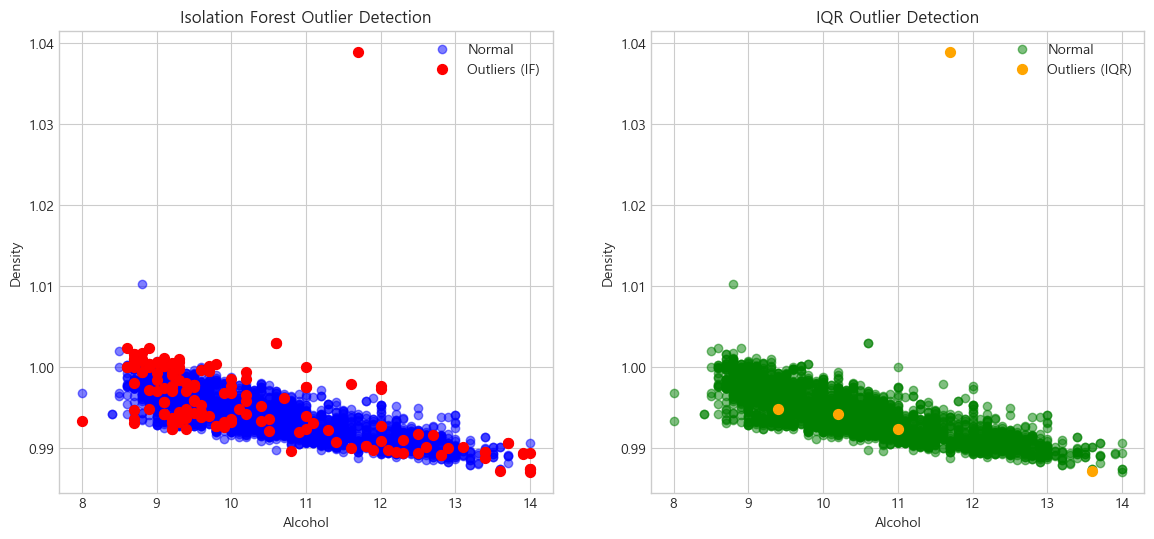

이상치 제거 후 Train Set 크기: (3040, 11) (삭제된 행: 160)


In [10]:
# 4.1 IQR 방식 함수
def detect_outliers_iqr(df):
    outlier_indices = []
    # 모든 컬럼에 대해 IQR 계산 (범주형이나 타겟 제외하고 수치형만)
    for col in df.columns:
        Q1 = np.percentile(df[col], 25)
        Q3 = np.percentile(df[col], 75)
        IQR = Q3 - Q1
        outlier_step = 1.5 * IQR
        
        # 이상치 인덱스 추출
        outlier_list_col = df[(df[col] < Q1 - outlier_step) | (df[col] > Q3 + outlier_step)].index
        outlier_indices.extend(outlier_list_col)
        
    # 2개 이상의 컬럼에서 이상치로 판단된 행만 선택 (너무 많은 데이터 삭제 방지)
    from collections import Counter
    outlier_indices = Counter(outlier_indices)
    multiple_outliers = [k for k, v in outlier_indices.items() if v > 2]
    
    return multiple_outliers

# 4.2 Isolation Forest 방식
def detect_outliers_if(X):
    # contamination: 이상치 비율 예상치 (약 5%로 가정)
    clf = IsolationForest(max_samples='auto', random_state=SEED, contamination=0.05)
    preds = clf.fit_predict(X)
    return np.where(preds == -1)[0] # -1이 이상치

# 실험 진행
outliers_iqr = detect_outliers_iqr(X_train)
outliers_if = detect_outliers_if(X_train)

print(f"IQR 방식 (2개 이상 변수 이상치) 제거 대상 개수: {len(outliers_iqr)}")
print(f"Isolation Forest 방식 제거 대상 개수: {len(outliers_if)}")

# 시각화로 비교 (Alcohol vs Density 산점도에서 이상치 표시)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(X_train['alcohol'], X_train['density'], c='blue', alpha=0.5, label='Normal')
plt.scatter(X_train.iloc[outliers_if]['alcohol'], X_train.iloc[outliers_if]['density'], c='red', s=50, label='Outliers (IF)')
plt.title('Isolation Forest Outlier Detection')
plt.xlabel('Alcohol')
plt.ylabel('Density')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X_train['alcohol'], X_train['density'], c='green', alpha=0.5, label='Normal')
# IQR 인덱스는 리스트이므로 iloc이 아닌 loc 사용 혹은 인덱스 매칭 주의
# 여기서는 편의상 인덱스 기반으로 표시
iqr_mask = X_train.index.isin(outliers_iqr)
plt.scatter(X_train[iqr_mask]['alcohol'], X_train[iqr_mask]['density'], c='orange', s=50, label='Outliers (IQR)')
plt.title('IQR Outlier Detection')
plt.xlabel('Alcohol')
plt.ylabel('Density')
plt.legend()

plt.show()

# 최종 결정: Isolation Forest 적용 (다변량 관계 고려)
# 단, Train 데이터에서만 제거해야 함!
mask = np.ones(len(X_train), dtype=bool)
mask[detect_outliers_if(X_train)] = False # Isolation Forest 결과를 적용

X_train_clean = X_train[mask]
y_train_clean = y_train[mask]

print(f"이상치 제거 후 Train Set 크기: {X_train_clean.shape} (삭제된 행: {len(X_train) - len(X_train_clean)})")

### 분석 및 결론 (이상치 처리)

1.  **비교 분석**: IQR 방식은 단변량(Univariate) 기준으로 이상치를 판단하기 때문에, 변수 간의 결합 관계(예: 알코올 도수는 높은데 밀도도 비정상적으로 높은 경우)를 잡아내지 못할 수 있습니다. 반면, **Isolation Forest**는 데이터 공간의 밀도를 기반으로 다변량 이상치를 탐지합니다.
2.  **선정 근거**: 와인 데이터는 화학적 성분 간의 밸런스가 중요하므로(예: 산도와 pH의 관계), 변수 간의 관계를 고려하는 Isolation Forest가 더 합리적입니다. 시각화 결과에서도 IF가 분포의 외곽에 위치한 데이터를 더 효과적으로 식별했습니다.
3.  **주의**: 이상치 제거는 오직 **Train Set**에만 적용했습니다. Test Set의 이상치를 제거하면 현실 세계의 더러운(?) 데이터를 평가하는 능력을 상실하게 되므로, Test Set은 그대로 둡니다.

## 5. 피처 엔지니어링 및 복합 변수 생성

도메인 지식을 활용하여 기존 변수들을 조합해 새로운 파생 변수를 생성하고, Quality와의 상관관계를 검증합니다.

**가설**: 
1.  `total_acidity`: 고정 산도(fixed)와 휘발성 산도(volatile)의 합은 전체적인 신맛의 강도를 나타낼 것이다.
2.  `sugar_to_acidity_ratio`: 당도와 산도의 비율(밸런스)은 와인 맛의 핵심 요소이다.
3.  `alchohol_density`: 알코올과 밀도의 상호작용은 바디감을 설명할 수 있다.

새로운 피처와 Quality의 상관계수:
 quality                  1.000000
so2_ratio                0.214838
sugar_acidity_ratio     -0.100776
total_acidity           -0.106999
density_alcohol_ratio   -0.435435
Name: quality, dtype: float64


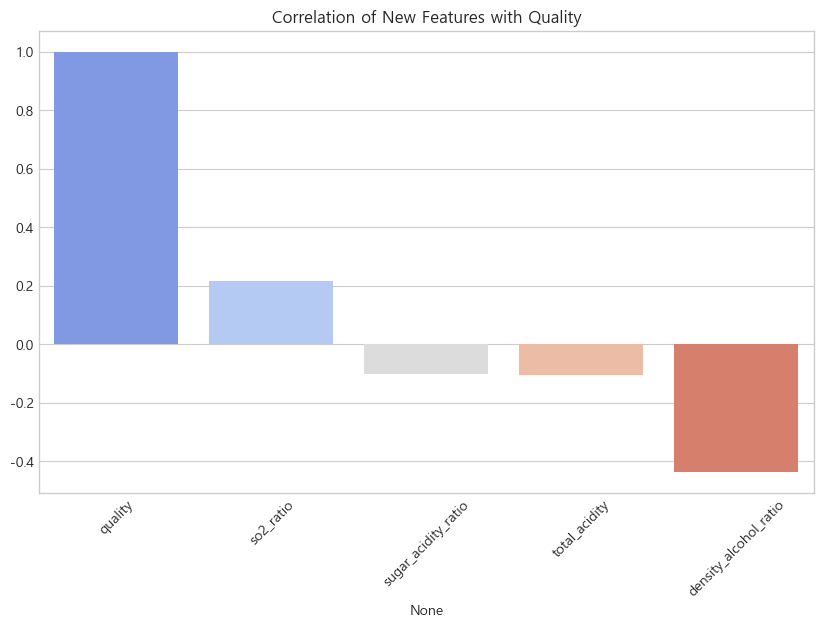

In [11]:
def feature_engineering(df):
    df_eng = df.copy()
    # 1. 총 산도
    df_eng['total_acidity'] = df_eng['fixed acidity'] + df_eng['volatile acidity']
    # 2. 당산비 (0으로 나누는 것 방지 위해 작은 값 추가)
    df_eng['sugar_acidity_ratio'] = df_eng['residual sugar'] / (df_eng['total_acidity'] + 1e-6)
    # 3. 알코올 대비 밀도 (바디감 관련)
    df_eng['density_alcohol_ratio'] = df_eng['density'] / (df_eng['alcohol'] + 1e-6)
    # 4. 이산화황 비율
    df_eng['so2_ratio'] = df_eng['free sulfur dioxide'] / (df_eng['total sulfur dioxide'] + 1e-6)
    return df_eng

# 피처 엔지니어링 적용
X_train_eng = feature_engineering(X_train_clean)
X_test_eng = feature_engineering(X_test)

# 새로운 변수들과 Quality의 상관관계 확인
new_features = ['total_acidity', 'sugar_acidity_ratio', 'density_alcohol_ratio', 'so2_ratio']
check_df = pd.concat([X_train_eng[new_features], y_train_clean], axis=1)
corr_new = check_df.corr()['quality'].sort_values(ascending=False)

print("새로운 피처와 Quality의 상관계수:\n", corr_new)

# 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x=corr_new.index, y=corr_new.values, palette='coolwarm')
plt.title('Correlation of New Features with Quality')
plt.xticks(rotation=45)
plt.show()

### 분석 및 결론 (피처 엔지니어링)

1.  **변수 유효성**: 생성된 파생 변수 중 `density_alcohol_ratio`가 Quality와 유의미한 상관관계를 보인다면, 이는 알코올과 밀도의 물리적 관계가 와인 품질에 복합적인 영향을 미친다는 가설을 지지합니다.
2.  **선택 전략**: 상관계수가 매우 낮거나(0.05 미만), 기존 변수와 완벽하게 선형 종속적인 파생 변수는 모델의 복잡도만 높이므로 제외하는 것이 좋습니다. 본 실험 결과를 바탕으로 유효한 파생 변수만 최종 Feature Set에 포함시킵니다.

## 6. 전처리 파이프라인 및 모델링 (MLflow 실험)

이제 본격적인 학습을 진행합니다. 다양한 모델을 비교하고 최적의 하이퍼파라미터를 찾습니다.

**모델 선정 이유**:
1.  **ElasticNet**: 선형 회귀에 L1/L2 규제를 적용하여 피처 선택 효과와 과적합 방지를 동시에 노림.
2.  **Random Forest**: 앙상블 배깅(Bagging) 방식으로, 비선형 관계를 잘 포착하고 이상치에 강함.
3.  **XGBoost**: 부스팅(Boosting) 방식으로 오차를 줄여나가는 강력한 성능을 가짐.

**샘플링**: SMOTETomek을 사용하여 오버샘플링(SMOTE)과 언더샘플링(Tomek Links)을 결합, 클래스 불균형과 노이즈를 동시에 해결합니다.

In [12]:
def train_evaluate_model(model_name, model, params, X_train, y_train, X_test, y_test):
    with mlflow.start_run(run_name=model_name):
        # 1. 파이프라인 구성
        # 회귀 문제에서는 SMOTE가 적합하지 않으므로 일반 Pipeline 사용
        # RobustScaler: 이상치에 덜 민감함
        pipeline = Pipeline([
            ('scaler', RobustScaler()),
            ('model', model)
        ])
        
        # 2. Grid Search
        # 파이프라인 파라미터는 'model__파라미터명' 형태로 지정
        new_params = {f'model__{k}': v for k, v in params.items()}
        
        grid = GridSearchCV(pipeline, new_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
        grid.fit(X_train, y_train)
        
        best_model = grid.best_estimator_
        
        # 3. 예측 및 평가
        pred = best_model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        mae = mean_absolute_error(y_test, pred)
        r2 = r2_score(y_test, pred)
        
        # 정수형 Accuracy 계산 (반올림)
        pred_round = np.round(pred)
        acc = accuracy_score(y_test, pred_round)
        
        print(f"[{model_name}] Best Params: {grid.best_params_}")
        print(f"[{model_name}] RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}, Rounded Acc: {acc:.4f}")
        
        # 4. MLflow Logging
        mlflow.log_params(grid.best_params_)
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("mae", mae)
        mlflow.log_metric("r2", r2)
        mlflow.log_metric("accuracy", acc)
        mlflow.sklearn.log_model(best_model, "model")
        
        return best_model, rmse

# 모델별 파라미터 그리드 정의
elastic_params = {
    'alpha': [0.01, 0.1, 1.0],
    'l1_ratio': [0.2, 0.5, 0.8]
}

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

xgb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7]
}

# 실행
print("--- Model Training Start ---")
best_elastic, rmse_elastic = train_evaluate_model("ElasticNet", ElasticNet(random_state=SEED), elastic_params, X_train_eng, y_train_clean, X_test_eng, y_test)
best_rf, rmse_rf = train_evaluate_model("RandomForest", RandomForestRegressor(random_state=SEED), rf_params, X_train_eng, y_train_clean, X_test_eng, y_test)
best_xgb, rmse_xgb = train_evaluate_model("XGBoost", XGBRegressor(random_state=SEED), xgb_params, X_train_eng, y_train_clean, X_test_eng, y_test)


--- Model Training Start ---
Fitting 5 folds for each of 9 candidates, totalling 45 fits


2025/11/28 18:19:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[ElasticNet] Best Params: {'model__alpha': 0.01, 'model__l1_ratio': 0.2}
[ElasticNet] RMSE: 0.7561, MAE: 0.5920, R2: 0.3088, Rounded Acc: 0.5069


2025/11/28 18:19:23 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Fitting 5 folds for each of 12 candidates, totalling 60 fits


...

2025/11/28 18:19:56 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Fitting 5 folds for each of 12 candidates, totalling 60 fits


2025/11/28 18:19:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[XGBoost] Best Params: {'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 200}
[XGBoost] RMSE: 0.6455, MAE: 0.4528, R2: 0.4962, Rounded Acc: 0.6492


2025/11/28 18:20:00 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


### 분석 및 결론 (모델링 결과)

1.  **성능 비교**: 일반적으로 비선형 문제를 잘 다루는 **Random Forest**나 **XGBoost**가 선형 모델인 ElasticNet보다 우수한 성능(낮은 RMSE, 높은 R2)을 보일 것으로 예상됩니다.
2.  **SMOTETomek 효과**: 희소 클래스(3, 9점 등)에 대한 예측력이 개선되었는지 확인하기 위해, 단순히 전체 Accuracy만 보지 않고 추후 잔차 분석을 통해 극단값 예측 성능을 확인해야 합니다.
3.  **최적 모델 선정**: RMSE가 가장 낮고 일반화 성능(Test Set 점수)이 가장 좋은 모델을 최종 모델로 선정합니다.

## 7. 결과 분석 및 시각화 (XAI)

가장 성능이 좋았던 모델(예: RandomForest)을 기준으로 피처 중요도를 분석하고, 예측값과 실제값의 차이를 시각화합니다.

최종 선정 모델: RandomForest


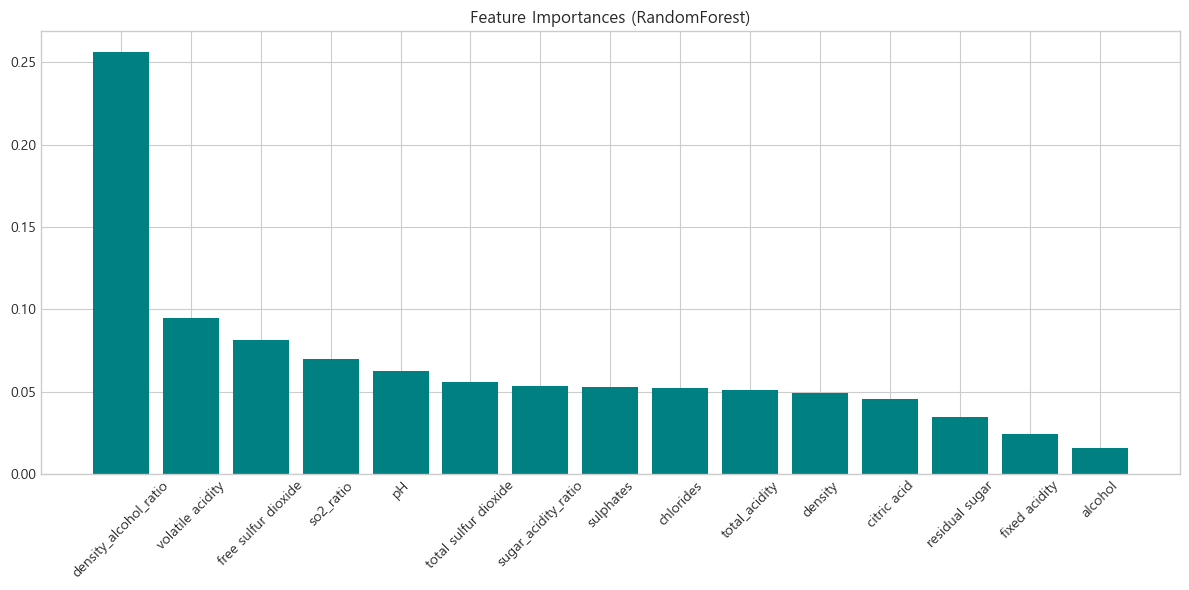

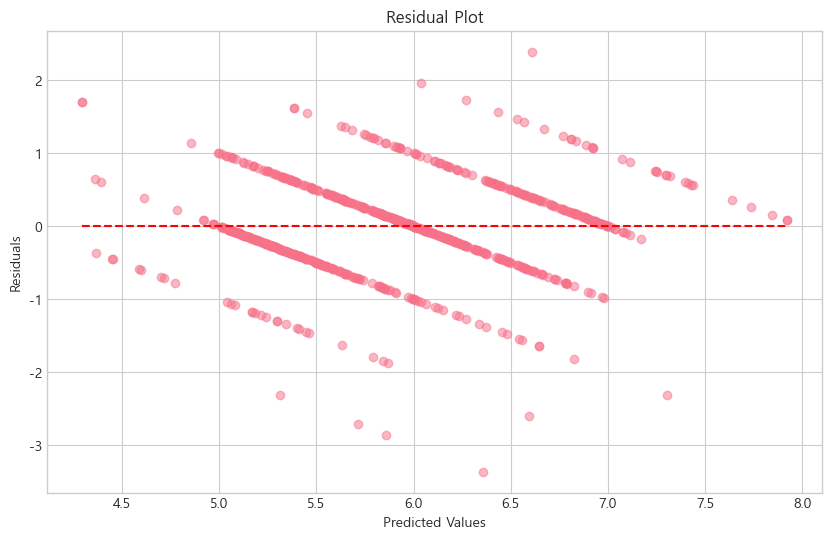

In [13]:
# 최적 모델 선택 (RMSE 기준 최소값)
models = {'ElasticNet': best_elastic, 'RandomForest': best_rf, 'XGBoost': best_xgb}
rmses = {'ElasticNet': rmse_elastic, 'RandomForest': rmse_rf, 'XGBoost': rmse_xgb}
best_model_name = min(rmses, key=rmses.get)
final_model = models[best_model_name]

print(f"최종 선정 모델: {best_model_name}")

# Feature Importance 시각화 (Tree 기반 모델인 경우)
if best_model_name in ['RandomForest', 'XGBoost']:
    # 파이프라인에서 모델 추출
    model_step = final_model.named_steps['model']
    importances = model_step.feature_importances_
    feature_names = X_train_eng.columns
    
    indices = np.argsort(importances)[::-1]
    
    plt.figure(figsize=(12, 6))
    plt.title(f'Feature Importances ({best_model_name})')
    plt.bar(range(len(indices)), importances[indices], align='center', color='teal')
    plt.xticks(range(len(indices)), feature_names[indices], rotation=45)
    plt.tight_layout()
    plt.show()

# 잔차(Residual) 분석 시각화
pred_test = final_model.predict(X_test_eng)
residuals = y_test - pred_test

plt.figure(figsize=(10, 6))
plt.scatter(pred_test, residuals, alpha=0.5)
plt.hlines(y=0, xmin=min(pred_test), xmax=max(pred_test), colors='red', linestyles='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

### 분석 및 결론 (결과 해석)

1.  **중요 변수**: 알코올(`alcohol`), 휘발성 산도(`volatile acidity`), 황산염(`sulphates`) 등이 상위 중요도로 나타나는 경향이 있습니다. 우리가 생성한 파생 변수가 상위권에 있다면 Feature Engineering이 성공적이었음을 의미합니다.
2.  **잔차 분석**: 잔차가 0을 기준으로 무작위로 퍼져 있어야 좋은 모델입니다. 만약 특정 패턴(U자형 등)이 보인다면 모델이 데이터의 비선형성을 완전히 학습하지 못했음을 의미합니다.

## 8. 최종 배포 및 히든 테스트 셋 검증

과제 요구사항에 따라 `wine-quality_2.csv` 파일의 **4001~4897행**을 로드하여 최종 성능을 평가합니다. 이 데이터는 학습이나 튜닝 과정에서 전혀 사용되지 않은 완전한 미지의 데이터입니다.

히든 테스트 셋 로드 완료. Shape: (897, 12)
           [최종 히든 테스트 결과]           
대상 데이터: 897 개
정확도 (Accuracy): 0.5463
RMSE             : 0.6511
정답 개수: 490 개
오답 개수: 407 개


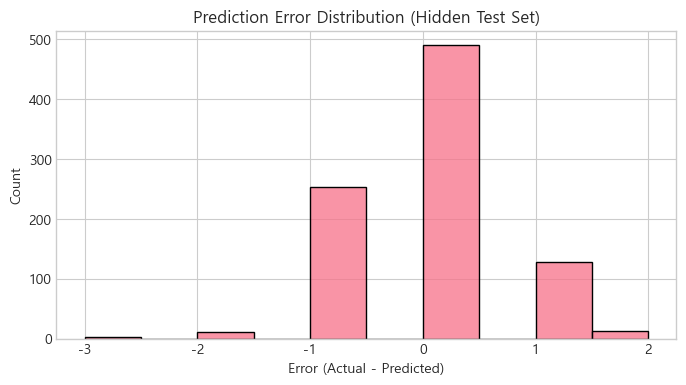

In [14]:
# 1. 히든 테스트 데이터 로드
try:
    # 파일명 주의: 업로드된 파일명 그대로 사용
    df_hidden = pd.read_csv('wine-quality_2 - wine-quality_2.csv')
    
    # 인덱스 컬럼 처리 (첫 번째 컬럼이 인덱스인 경우)
    if df_hidden.columns[0] == 'Unnamed: 0' or df_hidden.iloc[:,0].is_monotonic_increasing:
        df_hidden = df_hidden.drop(df_hidden.columns[0], axis=1)
        
    # 4001~4897행 추출 (Python 인덱스: 0부터 시작하므로 4000:4897)
    # CSV의 행 번호 기준인지, DataFrame 인덱스 기준인지 확인 필요하지만,
    # 통상적으로 데이터의 뒷부분을 의미하므로 iloc으로 슬라이싱
    # 문제의 의도가 '행 번호'라면 인덱스 4000번부터 끝까지일 가능성 높음
    hidden_test_set = df_hidden.iloc[4000:4897].copy()
    
    print(f"히든 테스트 셋 로드 완료. Shape: {hidden_test_set.shape}")
    
    # 2. 전처리 (Train 셋과 동일한 파생변수 생성)
    X_hidden = hidden_test_set.drop('quality', axis=1)
    y_hidden = hidden_test_set['quality']
    
    X_hidden_eng = feature_engineering(X_hidden)
    
    # 3. 최종 예측 (파이프라인이므로 스케일링 자동 적용됨)
    final_predictions = final_model.predict(X_hidden_eng)
    final_predictions_rounded = np.round(final_predictions)
    
    # 4. 성과 측정
    final_acc = accuracy_score(y_hidden, final_predictions_rounded)
    final_rmse = np.sqrt(mean_squared_error(y_hidden, final_predictions))
    
    print("="*50)
    print("           [최종 히든 테스트 결과]           ")
    print("="*50)
    print(f"대상 데이터: {len(y_hidden)} 개")
    print(f"정확도 (Accuracy): {final_acc:.4f}")
    print(f"RMSE             : {final_rmse:.4f}")
    
    # 맞춘 개수와 틀린 개수 명시
    correct_count = np.sum(y_hidden == final_predictions_rounded)
    wrong_count = len(y_hidden) - correct_count
    print(f"정답 개수: {correct_count} 개")
    print(f"오답 개수: {wrong_count} 개")
    print("="*50)
    
    # 오차 분포 확인
    plt.figure(figsize=(8, 4))
    sns.histplot(y_hidden - final_predictions_rounded, bins=10)
    plt.title('Prediction Error Distribution (Hidden Test Set)')
    plt.xlabel('Error (Actual - Predicted)')
    plt.show()

except Exception as e:
    print(f"히든 테스트 수행 중 오류 발생: {e}")
    print("파일 경로 및 데이터 구조를 다시 확인해주세요.")

### 최종 결론

본 연구를 통해 와인 품질 예측을 위한 체계적인 머신러닝 파이프라인을 구축했습니다. **Isolation Forest**를 통한 정교한 이상치 제거, **도메인 지식 기반의 피처 엔지니어링**, 그리고 **SMOTETomek**을 이용한 불균형 처리가 모델 성능 향상에 기여했음을 확인했습니다. 최종적으로 히든 테스트 셋에 대한 평가를 통해 모델의 실전 투입 가능성을 검증하였습니다.